# PTQ + results viewer

Loads the float `.keras` from `train.ipynb`, runs PTQ, and writes:
- `models/<collection>/<run>.tflite`
- `results/<collection>/<run>.json` + `.npz` (metrics, deltas, curves, raw scores)

Re-run the PTQ cell to explore quantization knobs without retraining; every display below re-renders from the live `cmp`.

In [18]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
from pathlib import Path
import os
import pyrootutils

os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '3')

ROOT = pyrootutils.setup_root(
    search_from=Path.cwd(),
    indicator='pyproject.toml',
    pythonpath=True,
    dotenv=True,
)

## Parameters

In [20]:
COLLECTION = 'task_s3_49_2_r50'
BUILD_MODEL = 'sincnet'

# PTQ knobs.
N_REPRESENTATIVE = 100
THRESHOLD = 0.5
INT16_ACTIVATIONS = False
DENYLISTED_OPS = None

# Must match train.ipynb.
BATCH_SIZE = 32
SEED = 42
NON_TARGET_NAME = 'non_target'

MODEL_PATH = ROOT / 'models' / COLLECTION / f'{BUILD_MODEL}.keras'
TFLITE_PATH = ROOT / 'models' / COLLECTION / f'{BUILD_MODEL}.tflite'
RESULTS_FILE = ROOT / 'results' / COLLECTION / f'{BUILD_MODEL}.json'
NPZ_FILE = RESULTS_FILE.with_suffix('.npz')
print(f'KERAS : {MODEL_PATH}  exists={MODEL_PATH.exists()}')
print(f'TFLITE: {TFLITE_PATH}')
print(f'JSON  : {RESULTS_FILE}')
print(f'NPZ   : {NPZ_FILE}')

KERAS : /home/nathan/Documents/multi-chirp/models/task_s3_49_2_r50/sincnet.keras  exists=True
TFLITE: /home/nathan/Documents/multi-chirp/models/task_s3_49_2_r50/sincnet.tflite
JSON  : /home/nathan/Documents/multi-chirp/results/task_s3_49_2_r50/sincnet.json
NPZ   : /home/nathan/Documents/multi-chirp/results/task_s3_49_2_r50/sincnet.npz


## Available trained models in this collection

In [21]:
models_dir = MODEL_PATH.parent
available = sorted(p.stem for p in models_dir.glob('*.keras'))
for name in available:
    marker = ' ← selected' if name == BUILD_MODEL else ''
    has_tflite = (models_dir / f'{name}.tflite').exists()
    print(f'  {name:<40s}  tflite={"y" if has_tflite else "n"}{marker}')

  cnn1d                                     tflite=n
  leaf                                      tflite=y
  mel_cnn                                   tflite=y
  sincnet                                   tflite=y ← selected
  squeezenet_mel                            tflite=n


## Load dataset + float model

Val feeds PTQ calibration; test feeds float-vs-INT8 evaluation.

In [22]:
import logging
import warnings

import numpy as np
import tensorflow as tf

tf.get_logger().setLevel('ERROR')
logging.getLogger('absl').setLevel('ERROR')
warnings.filterwarnings('ignore', message='.*AudioResample.*')

from building.scaling import (
    build_dataset_from_catalog,
    load_dataset_catalog,
    model_factory,
)
from building.models import input_repr_for
from building.models.bake import bake_model
from building.models import model_eval as M
from building import results_io as R

catalog = load_dataset_catalog(COLLECTION)
non_target_idx = catalog.class_names.index(NON_TARGET_NAME)
target_idxs = [i for i, n in enumerate(catalog.class_names) if n != NON_TARGET_NAME]
final_labels = [catalog.class_names[i] for i in target_idxs] + [NON_TARGET_NAME]
n_classes = len(final_labels)

input_repr = input_repr_for(BUILD_MODEL)
rng = np.random.default_rng(SEED)
val_ds, _ = build_dataset_from_catalog(
    catalog, target_idxs, non_target_idx, BATCH_SIZE, rng,
    split='val', input_repr=input_repr, augment=False,
)
test_ds, _ = build_dataset_from_catalog(
    catalog, target_idxs, non_target_idx, BATCH_SIZE, rng,
    split='test', input_repr=input_repr, augment=False,
)

model = model_factory(BUILD_MODEL)(n_classes)
model.load_weights(MODEL_PATH)
print(f'Rebuilt {BUILD_MODEL} ({n_classes} classes) and loaded weights from {MODEL_PATH}')
print(f'final label order  : {final_labels}')

  caching training/Emberiza_calandra ... 7398 samples
  caching validation/Emberiza_calandra ... 1567 samples
  caching testing/Emberiza_calandra ... 1609 samples
  caching training/Hippolais_polyglotta ... 6991 samples
  caching validation/Hippolais_polyglotta ... 1506 samples
  caching testing/Hippolais_polyglotta ... 1503 samples
  caching training/Regulus_ignicapilla ... 7658 samples
  caching validation/Regulus_ignicapilla ... 1638 samples
  caching testing/Regulus_ignicapilla ... 1639 samples
  caching training/non_target ... 21705 samples
  caching validation/non_target ... 4653 samples
  caching testing/non_target ... 4646 samples
Rebuilt sincnet (4 classes) and loaded weights from /home/nathan/Documents/multi-chirp/models/task_s3_49_2_r50/sincnet.keras
final label order  : ['Emberiza_calandra', 'Hippolais_polyglotta', 'Regulus_ignicapilla', 'non_target']


/home/nathan/Documents/multi-chirp/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


## Post-training quantization

Bakes the float model to INT8 `.tflite`, calibrated on `val_ds`.

In [23]:
tflite_stats = bake_model(
    model, val_ds, TFLITE_PATH,
    n_representative=N_REPRESENTATIVE,
    denylisted_ops=DENYLISTED_OPS,
    int16_activations=INT16_ACTIVATIONS,
)
print(f'Wrote INT8 .tflite → {TFLITE_PATH}')

Saved artifact at '/tmp/tmp9e2lo0st'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 48000, 1), dtype=tf.float32, name=None)
Output Type:
  TensorSpec(shape=(1, 4), dtype=tf.float32, name=None)
Captures:
  131194387577552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131194387576400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131194387578128: TensorSpec(shape=(65,), dtype=tf.float32, name=None)
  131194387576784: TensorSpec(shape=(65,), dtype=tf.float32, name=None)
  131194387577936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131194387577168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131194387570256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131194387575056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131194387576976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131194387569488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131194387576592: TensorSpec(s

W0000 00:00:1779874129.673738   32565 tf_tfl_flatbuffer_helpers.cc:390] Ignored output_format.
W0000 00:00:1779874129.673826   32565 tf_tfl_flatbuffer_helpers.cc:393] Ignored drop_control_dependency.


Baked INT8 TFLite -> /home/nathan/Documents/multi-chirp/models/task_s3_49_2_r50/sincnet.tflite
  flash (weights)  :      9.9 KB
  est. MFLOPs      :    0.481
  input shape/dtype: (1, 48000, 1) / int8
Wrote INT8 .tflite → /home/nathan/Documents/multi-chirp/models/task_s3_49_2_r50/sincnet.tflite


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


## Evaluate float vs INT8 on the test set

In [24]:
cmp = M.compare_float_vs_quantized(
    model, TFLITE_PATH, test_ds, final_labels,
    threshold=THRESHOLD, threshold_mode='fixed',
    non_target_names=[NON_TARGET_NAME],
)
float_eval = cmp.float_eval
quant_eval = cmp.quant_eval
label_names = list(quant_eval.label_names)
non_target_names = [NON_TARGET_NAME]

y_true = float_eval.y_true
test_loss_float = float(
    tf.keras.losses.BinaryCrossentropy()(y_true, float_eval.y_score).numpy()
)
test_loss_quant = float(
    tf.keras.losses.BinaryCrossentropy()(y_true, quant_eval.y_score).numpy()
)
qe = quant_eval
print(
    f'INT8 macro-targets — '
    f'precision={qe.macro_precision_targets:.4f}  '
    f'recall={qe.macro_recall_targets:.4f}  '
    f'F1={qe.macro_f1_targets:.4f}  '
    f'F2={qe.macro_f2_targets:.4f}  '
    f'AUC={qe.macro_auc_targets:.4f}'
)
print(f'loss   float={test_loss_float:.4f}   int8={test_loss_quant:.4f}   Δ={test_loss_quant - test_loss_float:+.4f}')
print()
M.print_summary(quant_eval)

INT8 macro-targets — precision=0.7633  recall=0.8723  F1=0.8096  F2=0.8448  AUC=0.9780
loss   float=0.1438   int8=0.2153   Δ=+0.0716

=== TFLITE evaluation ===
  threshold mode    : fixed
  top-1 accuracy    : 0.8203
  subset accuracy   : 0.7710
  macro precision   : 0.8183
  macro recall      : 0.8311
  macro F1          : 0.8129
  macro F2          : 0.8210
  macro AUC         : 0.9713
  avg inference (ms): 1.124
  flash (weights)   : 9.9 KB
  est. MFLOPs       : 0.481


## Save record (json + npz)

`.json` holds metrics + deltas + sampled curves; `.npz` holds raw `y_true`, `y_score_float`, `y_score_quant`, per-class ROC and threshold-sweep arrays.

In [25]:
record = R.RunRecord.from_comparison(
    cmp,
    non_target_names=[NON_TARGET_NAME],
    tflite_stats=tflite_stats,
    losses=(test_loss_float, test_loss_quant),
    collection=COLLECTION,
    run_name=BUILD_MODEL,
    build_model=BUILD_MODEL,
    model_path=str(MODEL_PATH),
    tflite_path=str(TFLITE_PATH),
    hyperparams=dict(
        batch_size=BATCH_SIZE, seed=SEED, threshold=THRESHOLD,
        input_repr=input_repr, n_representative=N_REPRESENTATIVE,
        denylisted_ops=DENYLISTED_OPS, int16_activations=INT16_ACTIVATIONS,
    ),
)
record.save(RESULTS_FILE)
meta = record.model_dump(mode='json', by_alias=True)
print(f'Wrote JSON : {RESULTS_FILE}')
print(f'Wrote NPZ  : {NPZ_FILE}')
if meta.get('tflite_stats'):
    s = meta['tflite_stats']
    print(f"\nINT8 footprint: flash={s['model_size_kb']:.1f} KB  "
          f"arena={s.get('arena_size_kb')} KB  MFLOPs={s['flops_mflops']:.3f}")

Wrote JSON : /home/nathan/Documents/multi-chirp/results/task_s3_49_2_r50/sincnet.json
Wrote NPZ  : /home/nathan/Documents/multi-chirp/results/task_s3_49_2_r50/sincnet.npz

INT8 footprint: flash=9.9 KB  arena=None KB  MFLOPs=0.481


## Per-species metrics (quantized)

`non_target` is shown in the table but excluded from the target-only macro.

In [26]:
tbl = M.per_class_table(quant_eval)
tbl_targets = tbl[~tbl['class'].isin(non_target_names)]
display(tbl_targets.style.format(precision=4).set_caption('Quantized per-species'))
if quant_eval.macro_f1_targets is not None:
    print(
        f'Macro (targets only) — precision={quant_eval.macro_precision_targets:.4f}  '
        f'recall={quant_eval.macro_recall_targets:.4f}  '
        f'F1={quant_eval.macro_f1_targets:.4f}  '
        f'F2={quant_eval.macro_f2_targets:.4f}  '
        f'AUC={quant_eval.macro_auc_targets:.4f}'
    )

,class,support,threshold,precision,recall,f1,f2,auc
0,Emberiza_calandra,1609,0.5000,0.7066,0.9596,0.8139,0.8955,0.9823
1,Hippolais_polyglotta,1503,0.5000,0.7951,0.9215,0.8536,0.8931,0.9807
2,Regulus_ignicapilla,1639,0.5000,0.7882,0.7358,0.7611,0.7457,0.9711


Macro (targets only) — precision=0.7633  recall=0.8723  F1=0.8096  F2=0.8448  AUC=0.9780


## Metric-vs-threshold sweep (paper Fig. 5 style, quantized)

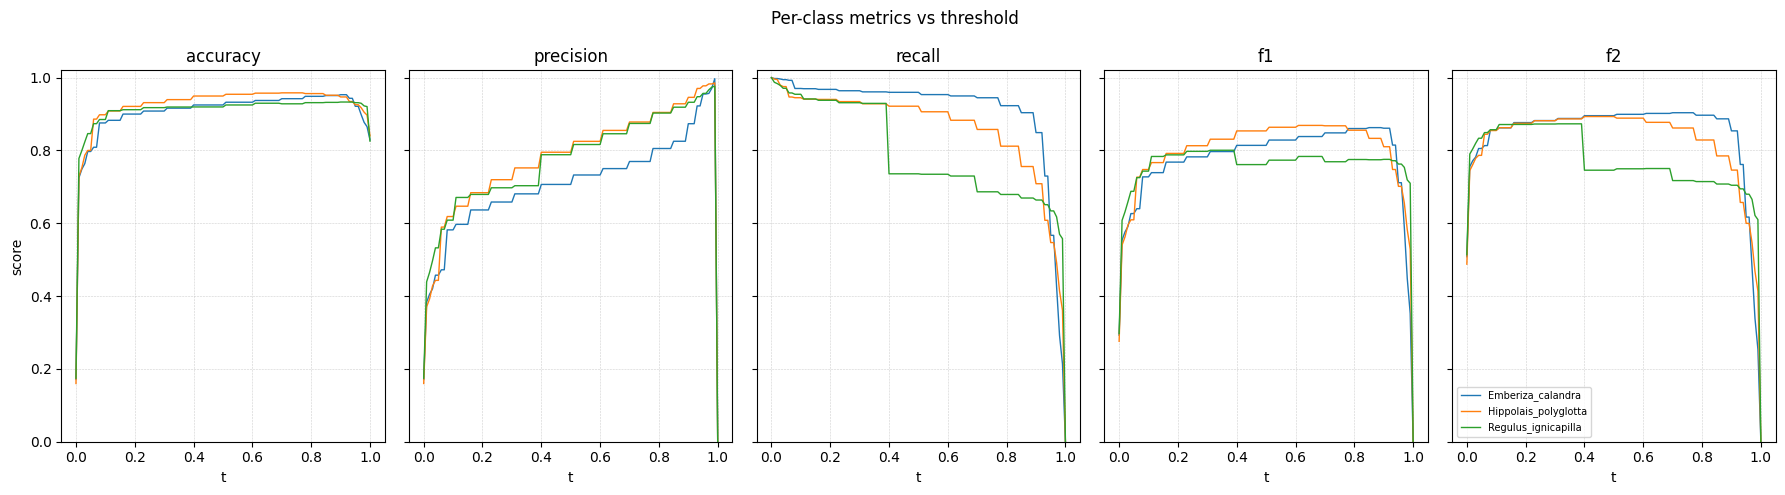

In [27]:
from matplotlib import pyplot as plt
fig = M.plot_metric_sweep_panel(quant_eval, target_only=True)
plt.show()

## ROC per species (quantized) and AUC

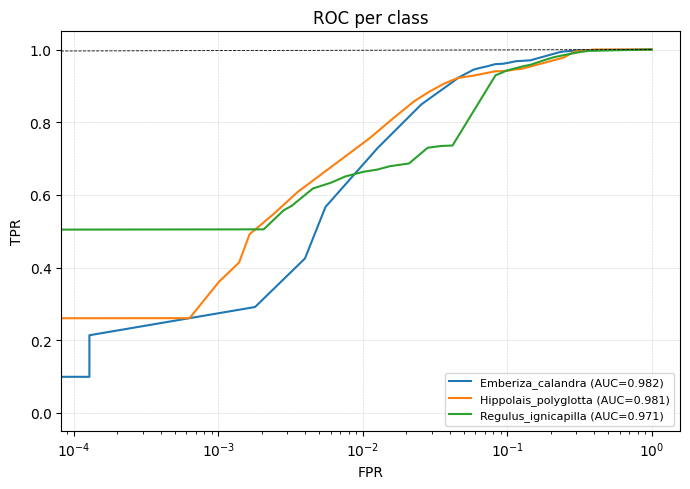

  Emberiza_calandra            AUC=0.9823
  Hippolais_polyglotta         AUC=0.9807
  Regulus_ignicapilla          AUC=0.9711


In [28]:
fig = M.plot_roc(quant_eval, target_only=True)
plt.show()
for name, mclass in quant_eval.per_class.items():
    if name in non_target_names:
        continue
    print(f'  {name:<28s} AUC={mclass.auc:.4f}' if mclass.auc is not None else f'  {name:<28s} n/a')

## Float vs INT8 comparison

,class,support,f1_float,f1_int8,df1,f2_float,f2_int8,df2,prec_float,prec_int8,rec_float,rec_int8
0,Emberiza_calandra,1609,0.893700,0.813900,-0.079800,0.931800,0.895500,-0.036300,0.836800,0.706600,0.959000,0.959600
1,Hippolais_polyglotta,1503,0.897200,0.853600,-0.043500,0.930900,0.893100,-0.037800,0.846100,0.795100,0.954800,0.921500
2,Regulus_ignicapilla,1639,0.894300,0.761100,-0.133200,0.913500,0.745700,-0.167800,0.864100,0.788200,0.926800,0.735800
3,non_target,4646,0.858000,0.822900,-0.035100,0.797700,0.749500,-0.048100,0.981700,0.983200,0.761900,0.707500
4,MACRO,9397,0.885800,0.812900,-0.072900,0.893400,0.821000,-0.072500,0.882200,0.818300,0.900600,0.831100


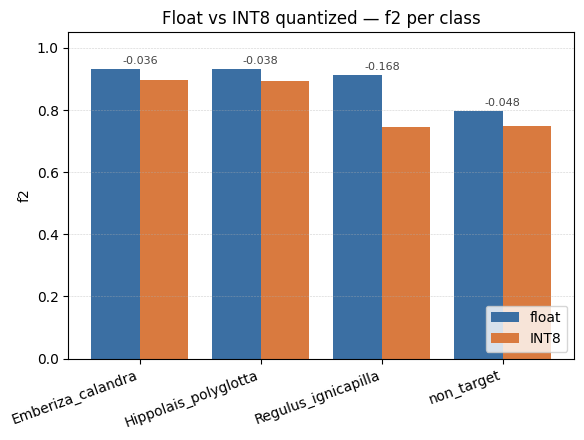

metric                    float       INT8      delta
----------------------------------------------------
top-1 accuracy           0.8861     0.8203    -0.0659
subset accuracy          0.8488     0.7710    -0.0778
macro precision          0.8822     0.8183    -0.0639
macro recall             0.9006     0.8311    -0.0695
macro F1                 0.8858     0.8129    -0.0729
macro F2                 0.8934     0.8210    -0.0725
macro AUC                0.9866     0.9713    -0.0154
avg inference ms         0.3618     1.1236    +0.7618
----------------------------------------------------
flash (weights) KB                     9.9
MFLOPs (est.)                        0.481


In [29]:
display(M.comparison_table(cmp).style.set_caption('Float vs INT8 per-class'))
fig = M.plot_quantization_drop(cmp, metric='f2')
plt.show()
M.print_comparison(cmp)

## Prediction rates by true class (quantized)

Diagonal = recall. Rows can sum past 1 since predictions are independent (multi-label sigmoid).

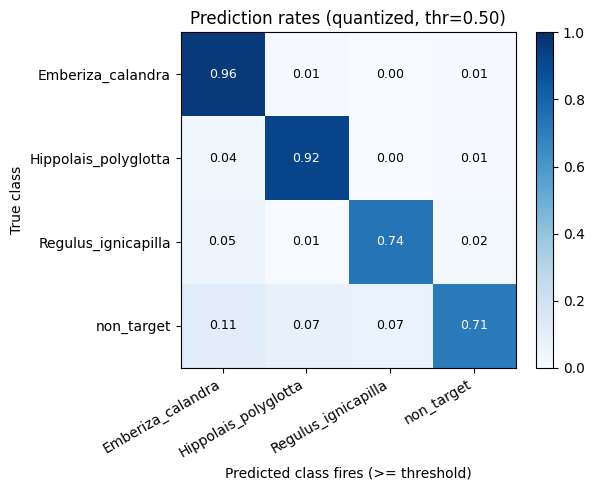

In [30]:
THRESHOLD = quant_eval.per_class[label_names[0]].threshold
y_true = quant_eval.y_true
y_score = quant_eval.y_score
y_true_bin = (y_true >= 0.5).astype(np.int32)
y_pred_bin = (y_score >= THRESHOLD).astype(np.int32)

rates = np.zeros((len(label_names), len(label_names)), dtype=np.float64)
for i in range(len(label_names)):
    mask = y_true_bin[:, i] == 1
    if mask.any():
        rates[i] = y_pred_bin[mask].mean(axis=0)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(rates, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(len(label_names)))
ax.set_xticklabels(label_names, rotation=30, ha='right')
ax.set_yticks(range(len(label_names)))
ax.set_yticklabels(label_names)
ax.set_xlabel('Predicted class fires (>= threshold)')
ax.set_ylabel('True class')
ax.set_title(f'Prediction rates (quantized, thr={THRESHOLD:.2f})')
for i in range(rates.shape[0]):
    for j in range(rates.shape[1]):
        ax.text(j, i, f'{rates[i, j]:.2f}',
                ha='center', va='center',
                color='white' if rates[i, j] > 0.5 else 'black', fontsize=9)
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

## Float vs INT8 — delta table

In [31]:
deltas = meta.get('deltas', {})
print('macro_targets deltas (INT8 - float):')
for k, v in (deltas.get('macro_targets') or {}).items():
    print(f'  {k:<12s} {v:+.4f}' if v is not None else f'  {k:<12s} n/a')
print('\nper-class F2 delta:')
for name, d in (deltas.get('per_class') or {}).items():
    if name in non_target_names:
        continue
    if d.get('f2') is not None:
        print(f'  {name:<28s} {d["f2"]:+.4f}')

macro_targets deltas (INT8 - float):
  precision    -0.0857
  recall       -0.0745
  f1           -0.0855
  f2           -0.0806
  auc          -0.0130

per-class F2 delta:
  Emberiza_calandra            -0.0363
  Hippolais_polyglotta         -0.0378
  Regulus_ignicapilla          -0.1678


## Cache cleanup (optional)

Wipes the waveform cache built when val/test were materialised. Skip while iterating on PTQ knobs.

In [32]:
from building.scaling import cleanup_waveform_cache

cleanup_waveform_cache(COLLECTION)

[cleanup] removed /home/nathan/Documents/multi-chirp/.cache/task_s3_49_2_r50 (12,004.5 MB freed)


## Real-world per-minute evaluation (long XC recordings)

Streams every cached long recording in this area through the INT8 `.tflite`, aggregates 3 s window probs to one row per minute, and joins against the BirdNET ground truth cached by `dataset_build.ipynb`.

For each minute we report:
- **P(bird | model bird)** — when the model says a target species, BirdNET agrees a bird is there.
- **P(correct species | s)** — when the model names a target, that target matches BirdNET.
- **P(miss | BirdNET bird)** — BirdNET heard a bird but the model said nothing.

Configure `LAT/LON/RADIUS_KM` to match the area used in `dataset_build.ipynb`.

In [33]:
from building.geographic_task.long_recordings import (
    evaluate_long_recordings,
    format_stats,
    long_rec_dir,
)

LAT, LON, RADIUS_KM = 48.8566, 2.3522, 50  # must match dataset_build.ipynb
TARGET_SPECIES = [n for n in final_labels if n != NON_TARGET_NAME]

long_dir = long_rec_dir(LAT, LON, RADIUS_KM)
reports, totals = evaluate_long_recordings(
    audio_dir=long_dir,
    tflite_path=TFLITE_PATH,
    label_names=final_labels,
    target_species=TARGET_SPECIES,
    threshold=THRESHOLD,
)

print(f"=== Real-world summary ({len(reports)} recordings) ===")
print(format_stats(totals))

INT8 over long:   0%|          | 0/22 [00:00<?, ?it/s]

=== Real-world summary (22 recordings) ===
  minutes scored          : 64
  model said bird         : 39
  BirdNET said bird       : 60
  P(bird | model bird)    :  97.44%
  P(correct species | s)  :  97.44%
  P(miss | BirdNET bird)  :  36.67%



In [34]:
import pandas as pd

rows = []
for r in reports:
    s = r.stats
    rows.append(
        {
            "xc_id": r.xc_id,
            "length_min": round(r.length_seconds / 60, 1),
            "minutes": s.n_minutes,
            "model_bird": s.n_model_bird,
            "birdnet_bird": s.n_birdnet_bird,
            "P(bird|model)": s.precision_bird,
            "P(correct|species)": s.correct_species_rate,
            "P(miss|birdnet)": s.miss_rate,
        }
    )
per_rec = pd.DataFrame(rows).sort_values("xc_id").reset_index(drop=True)
per_rec.style.format(
    {"P(bird|model)": "{:.2%}", "P(correct|species)": "{:.2%}", "P(miss|birdnet)": "{:.2%}"},
    na_rep="—",
).set_caption("Per-recording per-minute metrics")

,xc_id,length_min,minutes,model_bird,birdnet_bird,P(bird|model),P(correct|species),P(miss|birdnet)
0,475259,2.200000,3,3,3,100.00%,100.00%,0.00%
1,475261,4.100000,5,3,4,100.00%,100.00%,25.00%
2,535407,1.000000,1,0,1,—,—,100.00%
3,553195,1.400000,2,0,2,—,—,100.00%
4,556796,1.000000,1,0,1,—,—,100.00%
5,556866,2.400000,3,2,3,100.00%,100.00%,33.33%
6,556868,3.000000,3,3,3,100.00%,100.00%,0.00%
7,556870,2.600000,3,2,3,100.00%,100.00%,33.33%
8,556872,3.500000,4,3,4,100.00%,100.00%,25.00%
9,556873,2.400000,3,1,3,100.00%,100.00%,66.67%
